# 통계분석
# 1번
* 2년 전 제품 생산량이 100,000개, 1년 전 제품 생산량이 150,000개, 그 후 팩토리 기술의 상승으로 제품 생산량이 250,000개 되었을 때, 연평균 상승률의 대푯값을 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

In [12]:
import numpy as np

prod_2y = 100_000
prod_0y = 250_000 # 현재

# 전체 배수 (2.5배)
total_ratio = prod_0y / prod_2y

# 연평균 배수 (기하평균)
geo_mean_ratio = (total_ratio)**(1/2) # 1.5811...

geo_mean_ratio

1.5811388300841898

In [13]:
# 연평균 상승률 (배수 - 1)
avg_growth_rate = (geo_mean_ratio - 1) * 100

print(f'연평균 상승률: {round(avg_growth_rate, 2)}%')
# 결과: 58.11%

연평균 상승률: 58.11%


## 2번
12건의 광고시간 측정. 평균 15.5초, 분산 3.2초 일때 90% 신뢰구간은?
* 단, 정규분포를 따른다고 가정한다. 

In [21]:
from scipy import stats
import numpy as np

n = 12
mu = 15.5
var = 3.2
df = n - 1

# 표준오차(Standard Error) 계산
std_error = np.sqrt(var / n)

# Scipy 구버전 대응: confidence 대신 alpha 사용
# n이 작으므로(30 미만) t-분포를 사용하는 것이 적절합니다.
conf_interval = stats.t.interval(alpha=0.9, df=df, loc=mu, scale=std_error)

print(f'90% 신뢰구간: {conf_interval}')

90% 신뢰구간: (14.572609067393861, 16.427390932606137)


## 3번 문제 
강의 상류와 하류의 생물 다양성 점수에 차이가 있는지 검정하시오. (단, 같은 강에서 상류와 하류는 서로 독립적이지 않으며, 종속적인 관계에 있다.)
* a = 0.1

3.1 귀무가설과 대립가설을 세우시오

3.2 검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 검정하시오.


In [22]:
import pandas as pd
import numpy as np 

df = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/27_problem7.csv")
df

,river,up,down
0,a,57.1,45.7
1,b,51.6,37.2
2,c,53.9,53.3
3,d,59.0,54.3
4,e,57.5,46.3


귀무가설 : 상/하류간의 생물 다양성에는 차이가 없다 \
대립가설 : 상/하류간의 생물 다양성에는 차이가 있다.

3.2 검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 검정하시오.


In [23]:
# 강은 동일하나 처리만 바뀐 경우 (상류, 하류)

#대응표본 검정 

import scipy.stats as stats


stats.ttest_rel(df['up'],df['down']) ## default two-sided

## 유의 수준 0.1 
## 정규성이 만족한다고 가정한다. 

Ttest_relResult(statistic=3.3526056764717995, pvalue=0.028499777234053288)

p-value가 0.1보다 작으므로, 유의수준 0.1 하에서 귀무가설 기각한다.  

즉, 상 - 하류간 다양성에는 유의미한 차이가 있다고 할 수 있다. 


In [24]:
stats.wilcoxon(df['up'],df['down'])

WilcoxonResult(statistic=0.0, pvalue=0.0625)

비모수(wilcoxon) 검정: 실제 분석 환경에서는 샘플 수가 5개로 매우 적기 때문에 정규성을 확신하기 어려울 수 있습니다. 이때 wilcoxon 부호순위 검정을 병행하였다. 이 경우에도 p-value(0.0625)가 0.1보다 작아 동일하게 유의미한 차이가 있다는 결론에 도달한다. 

# 4번
user_counts를 종속변수로 하는 데이터이다

1. 분위수 회귀분석 (Quantile Regression) 을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

2.  1의 모델의 회귀계수를 활용하여 
temperature : 10.5 , wind : 8.2 ,precipitation : 3.5 일때 user_counts를 예측하시오


In [25]:
import pandas as pd
import numpy as np

df_user= pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/27_problem8.csv")
df_user

,temperature,wind,precipitation,user_counts
0,10.400000,4.600000,0.844944,6368
1,5.666667,4.625000,0.040860,5902
2,4.933333,4.725000,0.008696,6226
3,3.400000,2.675000,0.156989,5829
4,8.900000,3.950000,7.988462,7589
...,...,...,...,...
2092,3.500000,2.100000,0.024096,5430
2093,8.233333,2.000000,16.843820,2125
2094,9.500000,3.666667,11.550575,6008
2095,4.800000,1.200000,0.104651,4929


In [34]:
from sklearn.linear_model import QuantileRegressor

# 1. 데이터 준비 (전체 데이터 사용 권장)
X = df_user[['temperature', 'wind', 'precipitation']]
y = df_user['user_counts']

# 2. 모델 학습 (alpha=0 설정 필수)
model = QuantileRegressor(alpha=0) 
model.fit(X, y)

# 3. 회귀계수 및 절편 출력
print("절편(Intercept):", round(model.intercept_, 2))
print("temperature 기온 계수:", round(model.coef_[0], 2))
print("wind 풍속 계수:", round(model.coef_[1], 2))
print("precipitation 강수 계수:", round(model.coef_[2], 2))




절편(Intercept): 5941.87
temperature 기온 계수: 268.89
wind 풍속 계수: -129.41
precipitation 강수 계수: -83.38


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\sklearn\linear_model\_quantile.py:277: ConvergenceWarning: Linear programming for QuantileRegressor did not succeed.
Status is 4: Numerical difficulties encountered.
Result message of linprog:
The solution does not satisfy the constraints within the required tolerance of 3.16E-04, yet no errors were raised and there is no certificate of infeasibility or unboundedness. Check whether the slack and constraint residuals are acceptable; if not, consider enabling presolve, adjusting the tolerance option(s), and/or using a different method. Please consider submitting a bug report.
  ConvergenceWarning,


### 1) 분위수 회귀분석 (Quantile Regression) 을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

## 정답 : [ 268.89, -129.41,  -83.38]




###  1) 의 모델의 회귀계수를 활용하여 temperature : 10.5 , wind : 8.2 ,precipitation : 3.5 일때 user_counts를 예측하시오

In [44]:
X_new = [[10.5, 8.2, 3.5]]
print("최종 예측값:", round(model.predict(X_new)[0], 2))

최종 예측값: 7412.23


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but QuantileRegressor was fitted with feature names
  "X does not have valid feature names, but"


# 5번 문제
### 지하철 호선과 월별, 승객 수 간 상관관계가 있는지 확인(Type III Anova 사용)

1.귀무가설과 대립가설 설정하라


가. 상호작용효과 검정에 대한 가설

- 귀무가설 H0: 지하철 호선과 월별, 승객 수 간 상관관계가 없다.
- 대립가설 H1: 지하철 호선과 월별, 승객 수 간 상관관계가 있다.



나. 주효과 검정에 대한 가설

- 귀무가설 H0: 지하철 호선 승객 수 차이는 존재하지 않는다.
- 대립가설 H1: 지하철 호선 승객 수 차이는 존재한다.

- 귀무가설 H0: 월별 승객 수 차이는 존재하지 않는다.
- 대립가설 H1: 월별승객 수 차이는  차이는 존재한다.




In [1]:
import pandas as pd 
df = pd.read_csv("https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/27_problem9.csv")
df

,line,month,total
0,1,1,1310
1,1,2,1300
2,1,3,1305
3,1,4,1200
4,1,5,1301
...,...,...,...
67,3,8,1365
68,3,9,1374
69,3,10,1337
70,3,11,1332


In [2]:
## 분산분석 수행 

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

formula = 'total ~C(line)*C(month)' 
model = ols(formula, df).fit()
aov_table = anova_lm(model, typ=3)
aov_table

,sum_sq,df,F,PR(>F)
Intercept,3.466344e+06,1.0,33455.335657,4.849033e-55
C(line),1.336630e+05,2.0,645.022520,6.417946e-29
C(month),3.942483e+04,11.0,34.591616,7.896179e-16
C(line):C(month),9.696908e+04,22.0,42.540665,1.582232e-19
Residual,3.730000e+03,36.0,NaN,NaN


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


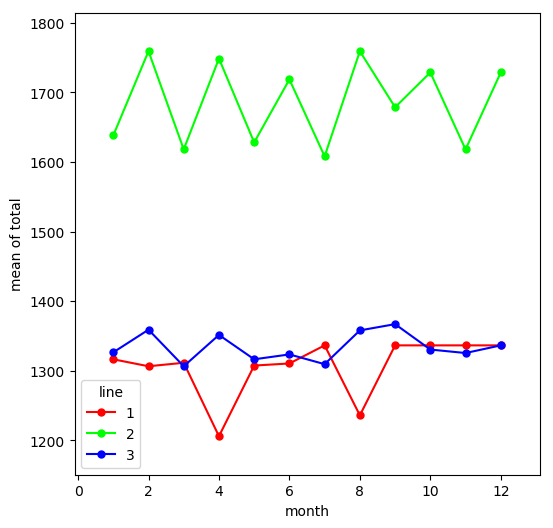

In [3]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

## Series로 변경 
total = df["total"]
line = df["line"]
month = df["month"]

fig, ax = plt.subplots(figsize=(6, 6))
fig = interaction_plot(month,line, total,ms=10, ax=ax)

### 결론 : 교호작용이 존재한다. 

1. 결과 테이블의 C(line):C(month)를보면 서로의 차이를 총분산으로 설명하는 F- value에 대한 P-value가 0.05보다 작다. 즉, 둘의 상관관계는 존재한다. 

* 일반적으로 상호작용 그래프에서 두 선이 서로 교차하고 있을 시에는 x축에 있는 독립변수와 그래프에서 시각화된 독립변수 간에는 상호작용이 존재한다고 해석할 수 있다.

## 지하철 승객 수 분석 결과 요약 (Type III ANOVA)
제시된 분석 결과에 따르면, 지하철 호선과 월별 요인은 승객 수(total)에 대하여 개별적으로뿐만 아니라 서로 결합하여서도 유의미한 영향을 미치는 것으로 나타났습니다.

지하철 호선과 월(Month) 사이에는 유의미한 상호작용 효과가 존재합니다. 즉, 특정 호선의 승객 수 변화 패턴이 월에 따라 다르게 나타나며, 두 변수 간의 관계가 독립적이지 않음을 의미합니다.

상호작용 그래프에서 선들이 서로 교차하거나 평행하지 않은 모습을 보이는 것은 통계적 검정 결과와 일치합니다.

교차 현상: 특정 월에는 1호선의 승객이 많다가 다른 월에는 2호선의 승객이 더 많아지는 등, 호선별 승객 추이가 월에 따라 다르게 변하고 있음을 시각적으로 증명합니다.

### 종합 결론
분석 결과, 지하철 호선과 월은 승객 수에 대하여 독립적이지 않으며 상호작용(상관관계)이 존재한다고 결론지을 수 있습니다. 따라서 승객 수를 예측하거나 분석할 때는 호선과 월을 각각 분리해서 보기보다, "특정 호선의 특정 달"이라는 결합된 맥락을 고려하는 것이 중요합니다.